<a href="https://colab.research.google.com/github/Ily17as/GA_for_TSM/blob/main/GA_for_Traveling_salesman_problem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Agenda:**
- Traveling salesman problem
- Feel free to change code as you wish


# The Travelling Salesman Problem

Find the shortest round trip through $n$ cities.

How can you solve these problem?
- exhaustive search
- However, if $P≠NP$, we can not expect any fast algorithm to emerge, ever
- The exhaustive search will let you solve problems up to 15 cities in few days
- Held-Karp algorithm let you solve instances up to 30–50 cities, optimistically
- Christofides Algorithm will give you a solution in a short amount of time that is at most 50% longer than the shortest round trip

### Crossover Example
![](https://github.com/RufinaMay/CV2019Fall_Pictures/blob/master/crossover1.png?raw=true)

![](https://github.com/RufinaMay/CV2019Fall_Pictures/blob/master/crossover2.png?raw=true)

![](https://github.com/RufinaMay/CV2019Fall_Pictures/blob/master/crossover3.png?raw=true)

![](https://github.com/RufinaMay/CV2019Fall_Pictures/blob/master/traveling_salesman.gif?raw=true)

## Initial data

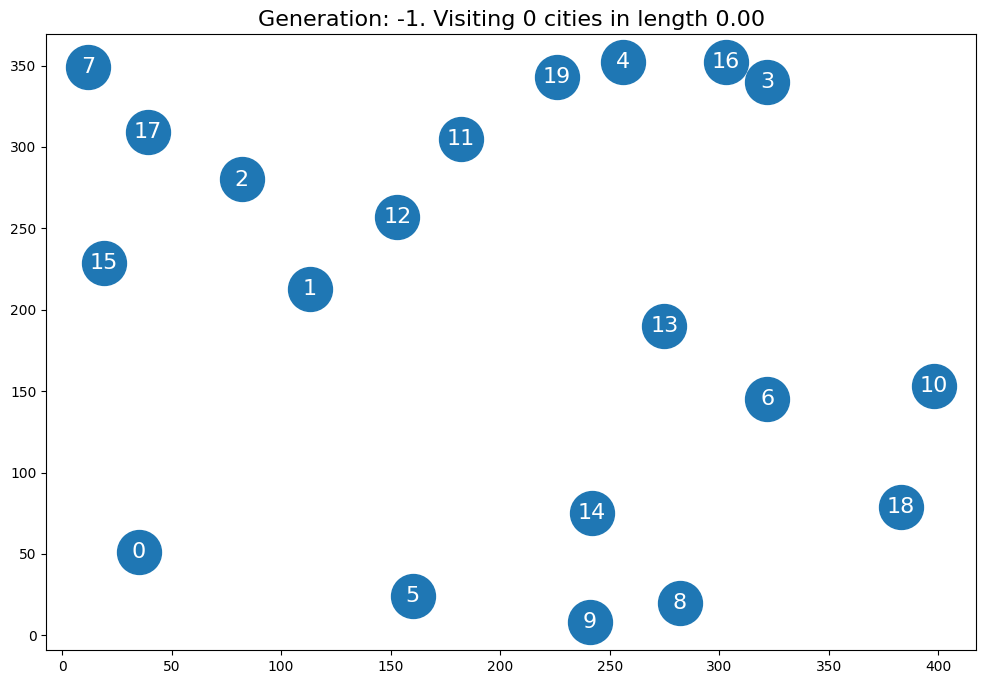

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import imageio

cities = np.array([[35, 51],
                   [113, 213],
                   [82, 280],
                   [322, 340],
                   [256, 352],
                   [160, 24],
                   [322, 145],
                   [12, 349],
                   [282, 20],
                   [241, 8],
                   [398, 153],
                   [182, 305],
                   [153, 257],
                   [275, 190],
                   [242, 75],
                   [19, 229],
                   [303, 352],
                   [39, 309],
                   [383, 79],
                   [226, 343]])

def compute_distances(cities):
    distances = []
    for from_city in cities:
        row = []
        for to_city in cities:
            row.append(np.linalg.norm(from_city - to_city))
        distances.append(row)
    return np.array(distances)

def create_fitness(cities):
    # Returns a fitness function for evaluating routes
    # The fitness function calculates the negative of the total distance traveled.

    def fitness(individual):
        # Initialize the total distance variable
        res = 0
        for i in range(len(individual)):
            res += distances[individual[i], individual[(i + 1) % len(individual)]]

        # Return the negative of the total distance for sorting in ascending
        return -res

    return fitness

def route_length(distances, route):
    length = 0
    for i in range(len(route)):
        length += distances[route[i], route[(i + 1) % len(route)]]
    return length

def plot_route(cities, route, distances, generation, show=False):
  # plots cities and route
  length = route_length(distances, route)

  plt.figure(figsize=(12, 8))
  plt.scatter(x=cities[:, 0], y=cities[:, 1], s=1000, zorder=1)
  for i in range(len(cities)):
      plt.text(cities[i][0], cities[i][1], str(i), horizontalalignment='center', verticalalignment='center', size=16, c='white')
  for i in range(len(route)):
      plt.plot([cities[route[i]][0], cities[route[(i + 1) % len(route)]][0]],
                [cities[route[i]][1], cities[route[(i + 1) % len(route)]][1]], 'k', zorder=0)

  plt.title(f'Generation: {generation}. Visiting {len(route)} cities in length {length:.2f}', size=16)

  if show:
    plt.show()

  plt.savefig(f'{generation}.png')
  plt.close()

distances = compute_distances(cities)
fitness = create_fitness(distances)  # Precompute fitness function with distances
plot_route(cities, route=[], distances=distances, generation=-1, show=True)

233.77339455121918

## Implementation

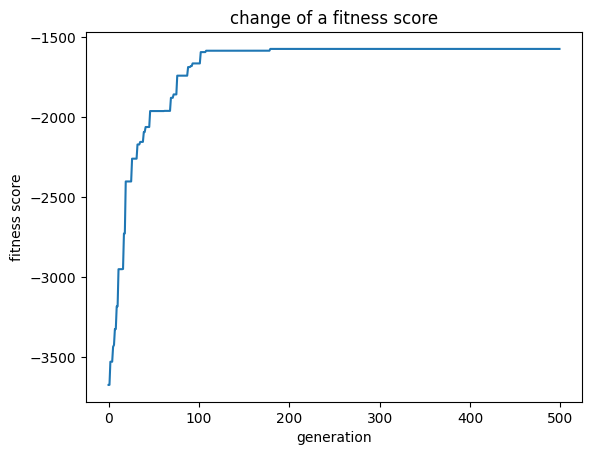

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import imageio

def get_individual(n_cities):
    # Ensure the individual contains all city indices without replacement.
    return np.random.choice(range(n_cities), n_cities, replace=False)

def initial_population(n_cities, population_size, fitness):
  population = [get_individual(n_cities) for _ in range(population_size)]
  population.sort(key=lambda x: fitness(x))
  return population

def get_parents(population, n_offsprings):
  # here we take the most fit parents for crossover
  mothers = population[-2 * n_offsprings::2]
  fathers = population[-2 * n_offsprings + 1::2]

  return mothers, fathers

def cross(mother, father):
    # Cross two parents together to create a new offspring.

    mother_head = mother[:int(len(mother) * 0.5)].copy()
    mother_tail = mother[int(len(mother) * 0.5):].copy()
    father_head = father[:int(len(mother) * 0.5)].copy()
    father_tail = father[int(len(father) * 0.5):].copy()

    # Mapping from cities in the father_tail to cities in the mother_tail.
    gen_dictionary = {}
    for i in range(len(father_tail)):
      gen_dictionary[father_tail[i]] = mother_tail[i]

    # Check if the current city in mother_head exists in father_tail.
    # Replace the city in mother_head with its mapped value from the mapping dictionary.
    for i in range(len(mother_head)):
      while mother_head[i] in father_tail:
        mother_head[i] = gen_dictionary[mother_head[i]]

    # Combine the modified mother_head and father_tail to form the new offspring.
    children = []
    children.extend(mother_head)
    children.extend(father_tail)

    return children

def mutate(offspring):
    # Mutate the given offspring by swapping two cities.
    i, j = np.random.choice(offspring, 2, replace=True)

    offspring[i], offspring[j] = offspring[j], offspring[i]
    return offspring

def replace_population(population, new_individuals, fitness):
    # Replace the current population with new individuals, keeping the fittest.
    size = len(population)
    population.extend(new_individuals)
    population.sort(key=lambda x: fitness(x))

    return population[-size:]

def evolution_step(population, population_size, fitness, n_offsprings):
  mothers, fathers = get_parents(population, n_offsprings)
  offsprings = []

  for mother, father in zip(mothers, fathers):
      offspring = mutate(cross(mother, father))
      offsprings.append(offspring)

  new_population = replace_population(population, offsprings, fitness)
  return new_population

def evolution(n_cities, fitness, population_size=100, n_offsprings=30, generations=10):
  fitness_change = []
  population = initial_population(n_cities, population_size, fitness)

  for generation in range(generations):
    population = evolution_step(population, population_size, fitness, n_offsprings)
    best_individual = population[-1]
    fitness_change.append(fitness(best_individual))
    plot_route(cities, route=best_individual, distances=distances, generation=generation)

  return fitness_change

generations=500
fitness_change = evolution(len(cities), create_fitness(cities), population_size=100, n_offsprings=30, generations=generations)


plt.plot(fitness_change)
plt.title('change of a fitness score')
plt.xlabel('generation')
plt.ylabel('fitness score')
plt.show()

<ipython-input-17-110c5230d025>:5: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(f'{generation}.png')


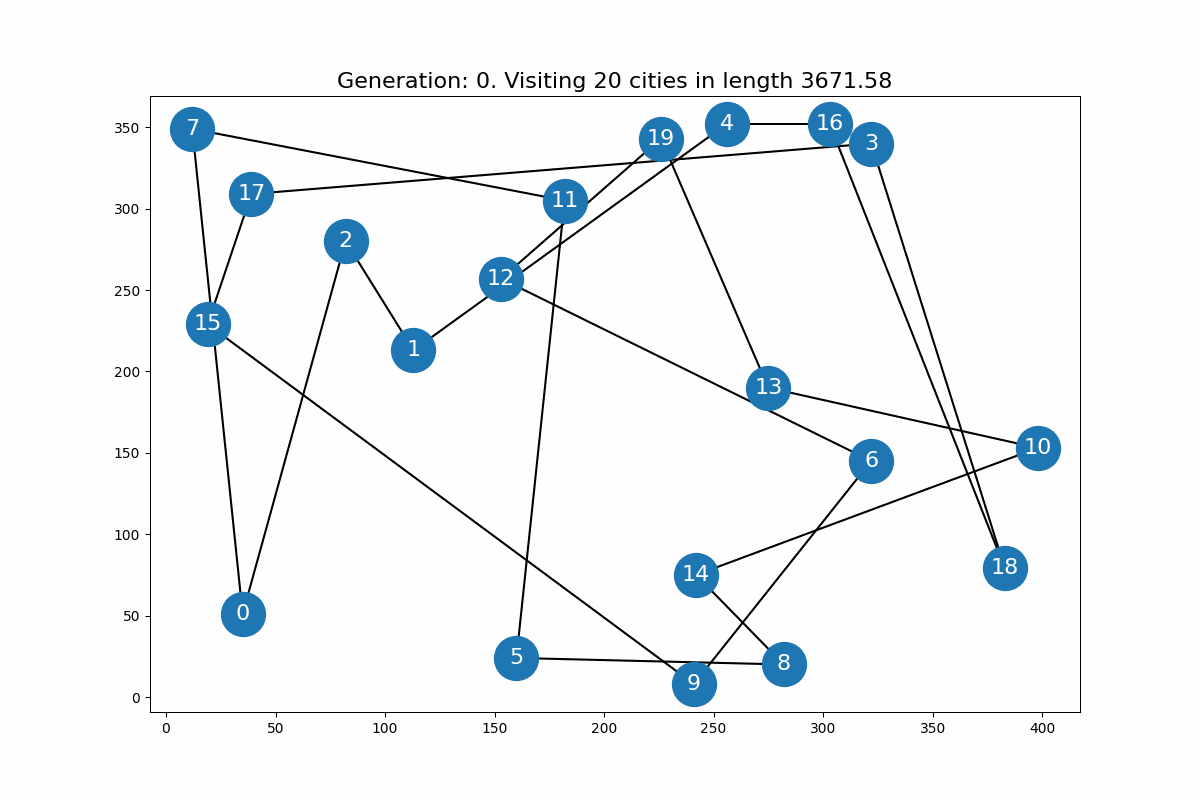

In [ ]:
from IPython.display import Image

with imageio.get_writer('mygif.gif', mode='I') as writer:
    for generation in range(generations):
        image = imageio.imread(f'{generation}.png')
        writer.append_data(image)

Image(open('mygif.gif','rb').read())

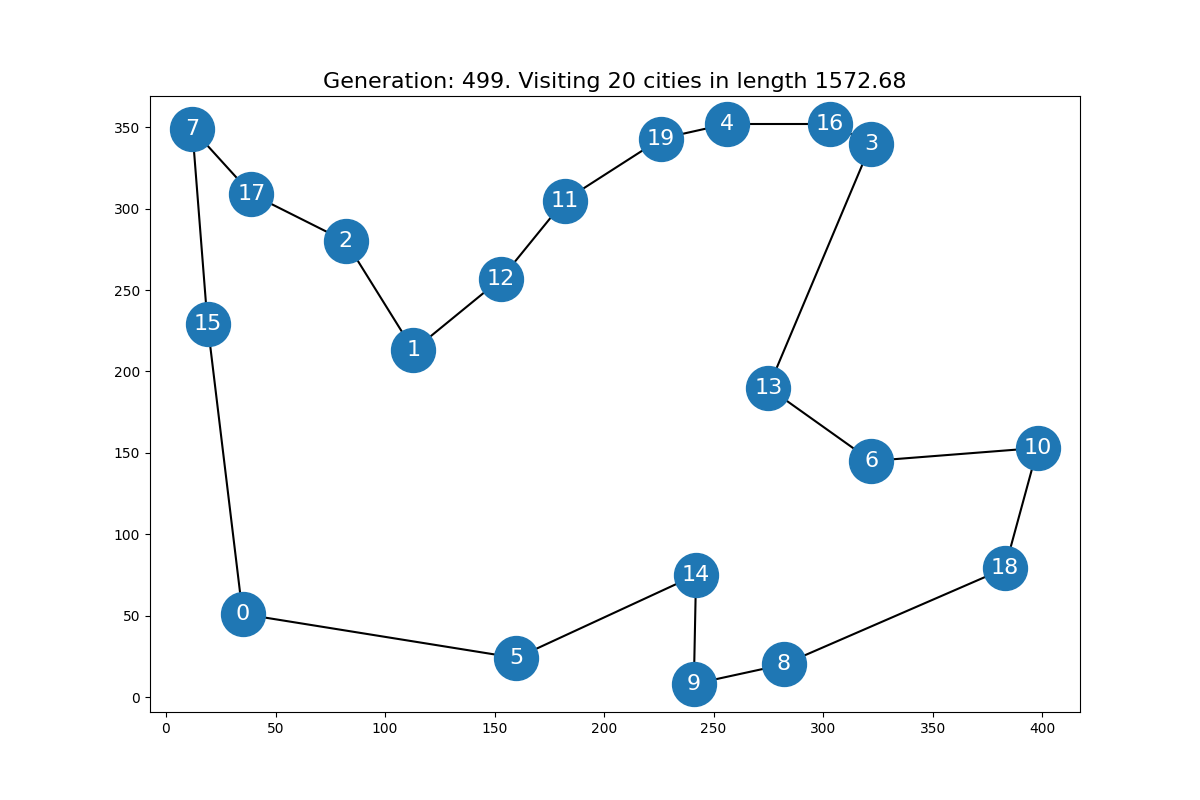

In [ ]:
Image(open(f'{generations-1}.png','rb').read())

In [ ]:
from google.colab import drive
drive.mount('/content/drive')